# money

Each row is a daily exchange rate for a national currency.

- `Date` day in YYYY-MM-DD format
- `Country` country name (not a currency code)
- `Exchange rate` price of 1 USD in that currency

https://github.com/datasets/exchange-rates/tree/main

## project idea

Choose some currencies and measure how stable they are.

This question is a bit vague for at least two reasons: there are many ways to define _stable_, and there is no international standard unit for prices.

For length or mass, we can use meters or grams.
What unit do we use for money? _The Economist_, a British magazine, created the [Big Mac index] to explain this problem. Their standard unit is a specific 汉堡 from McDonald's. Central banks often choose a _basket_ (weighted average) of multiple currencies.

I chose a simple basket and definition of _stable_.
Repeat this study with a different basket and/or stability measure. Are your conclusions similar to mine?

[Big Mac index]: https://statbase.org/datasets/indexes-and-ratings/bigmac-index/

In [1]:
from pathlib import Path
import pandas as pd

# This sets plotting style
import matplotlib.pyplot as plt
plt.style.use('bmh')
plotkw = {"figsize": (8, 2), "grid": True}

In [2]:
# Where is the dataset?
DATA_PATH = Path.cwd().parent / "data/prices/money.csv"

In [3]:
def clean_cols(data):
    # Standardize a DataFrame's column names
    return [x.lower().replace(' ', '_') for x in data.columns]

In [4]:
# Read the raw data
money = pd.read_csv(DATA_PATH)
money.columns = clean_cols(money)

# Convert date-like strings to Timestamp type
money['date'] = pd.to_datetime(money['date'])

# The original table is "tall." I want a "wide" table:
# dates are the index, and every other column is a country.
# Many spreadsheets call this a "pivot table."
# It can also be made with .groupby() and .unstack()
money = money.pivot(
        index='date',
        columns='country',
        values='exchange_rate'
)
money.columns = clean_cols(money)

# For this study, I only want 21st century dates.
money = money.loc['2001-01-01':]

# Exchange rates are in units of 1/USD. For example, 7 CNY
# is about 1 USD. When the USD price of CNY increases,
# a plot of CNY will go *down*. I find this confusing,
# so I converted everything to USD units.
money = 1 / money

money.tail()

,australia,austria,belgium,brazil,canada,china,denmark,euro,finland,france,...,south_africa,south_korea,spain,sri_lanka,sweden,switzerland,taiwan,thailand,united_kingdom,venezuela
date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,0.654707,NaN,NaN,0.185763,0.714898,0.140449,0.155872,1.164144,NaN,NaN,...,0.057897,0.000703,NaN,0.003300,0.106097,1.253918,0.032676,0.030727,1.335648,0.004971
2025-11-01,0.650195,NaN,NaN,0.187213,0.711440,0.140708,0.154780,1.155802,NaN,NaN,...,0.058039,0.000685,NaN,0.003266,0.105169,1.244245,0.032119,0.030893,1.313888,0.004267
2025-12-01,0.664319,NaN,NaN,0.183295,0.724900,0.141981,0.156779,1.170960,NaN,NaN,...,0.059408,0.000682,NaN,0.003235,0.107602,1.254863,0.031896,0.031671,1.338688,0.003688
2026-01-01,0.679209,NaN,NaN,0.187561,0.726164,0.143488,0.157203,1.174398,NaN,NaN,...,0.061491,0.000687,NaN,0.003231,0.110015,1.266785,0.031728,0.031974,1.353546,0.002976
2026-02-01,0.706015,NaN,NaN,0.192352,0.732708,0.144793,0.158288,1.182452,NaN,NaN,...,0.062525,0.000691,NaN,0.003233,0.111250,1.293828,0.031776,0.032005,1.357958,0.002553


In [5]:
# All values should be floats. Are they?
sorted(set(money.dtypes))

[dtype('float64')]

In [6]:
# Many European countries switched to EUR.
# Their exchange rates will be NaN after switching.
money.isnull().sum().nlargest(10)

greece         302
austria        290
belgium        290
finland        290
france         290
germany        290
ireland        290
italy          290
netherlands    290
portugal       290
dtype: int64

In [7]:
# I chose these 5 currencies for my basket.
# I looked up these values for 2026-01-01.
# Check that our dataset agrees with them.
basketcols = [
    'united_kingdom', # 1 GBP = 1.35 USD
    'switzerland',    # 1 CHF = 1.27 USD
    'euro',           # 1 EUR = 1.17 USD
    'singapore',      # 1 SGD = 0.78 USD
    'canada',         # 1 CAD = 0.73 USD
]
money.loc['2026-01-01', basketcols]

united_kingdom    1.353546
switzerland       1.266785
euro              1.174398
singapore         0.781433
canada            0.726164
Name: 2026-01-01 00:00:00, dtype: float64

In [8]:
# Imagine that in 2001-01-01, I invested $0.20 USD in each of
# those 5 currencies. I put that money in a basket, locked
# the basket in a safe place, and never spent any of it.
# How much of each currency would I have?
basket_coefs = 0.2 / money.loc['2001-01-01', basketcols]
basket_coefs

united_kingdom    0.13536
switzerland       0.32610
euro              0.21332
singapore         0.34760
canada            0.30064
Name: 2001-01-01 00:00:00, dtype: float64

<Axes: xlabel='date', ylabel='USD'>

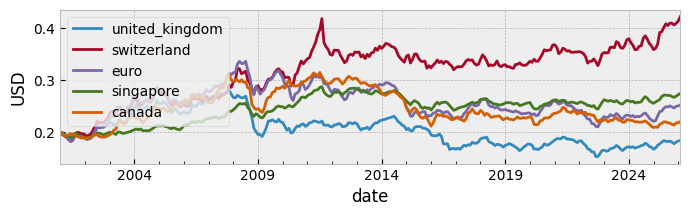

In [9]:
# Show the USD price of my investments over time.
basket = basket_coefs * money[basketcols]
basket.plot(**plotkw, ylabel='USD')

<Axes: xlabel='date', ylabel='USD'>

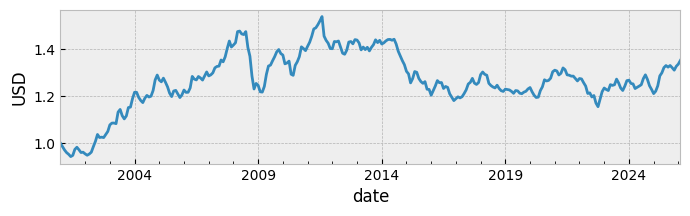

In [10]:
# Invent a fictional "world basket" currency called BKT.
# 1 BKT = whatever the total value of my basket is.
# On each day, 1 BKT is worth how many USD?
bkt = basket.sum(axis=1)
bkt.plot(**plotkw, ylabel='USD')

Since 2001-01-01,
1 unit of china money was worth at least 0.094 BKT
1 unit of china money had a mean value of 0.113 BKT
1 unit of china money was worth at most 0.128 BKT
(max - min) was 31% of mean


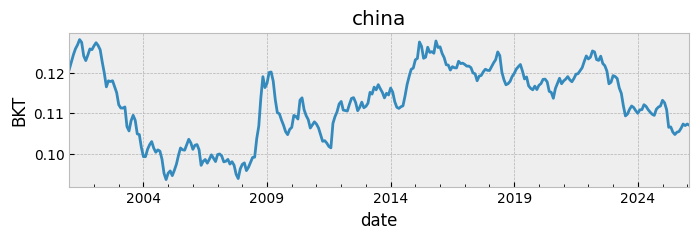

In [11]:
def bkt_price(country):
    # Show the price of a currency in BKT units.
    # Calculate a simple measure of instability:
    # (max - min) / mean since the first day in the table.
    val = (money[country] / bkt)
    minval, meanval, maxval = val.min(), val.mean(), val.max()
    print("Since 2001-01-01,")
    print(f"1 unit of {country} money was worth at least {minval:.3f} BKT")
    print(f"1 unit of {country} money had a mean value of {meanval:.3f} BKT")
    print(f"1 unit of {country} money was worth at most {maxval:.3f} BKT")
    print(f"(max - min) was {round((maxval - minval) / meanval * 100)}% of mean")
    val.plot(**plotkw, ylabel='BKT', title=f"{country}")

bkt_price('china')

Since 2001-01-01,
1 unit of new_zealand money was worth at least 0.423 BKT
1 unit of new_zealand money had a mean value of 0.528 BKT
1 unit of new_zealand money was worth at most 0.604 BKT
(max - min) was 34% of mean


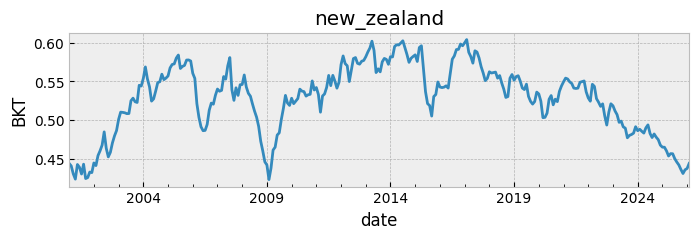

In [12]:
bkt_price('new_zealand')

Since 2001-01-01,
1 unit of australia money was worth at least 0.489 BKT
1 unit of australia money had a mean value of 0.600 BKT
1 unit of australia money was worth at most 0.750 BKT
(max - min) was 44% of mean


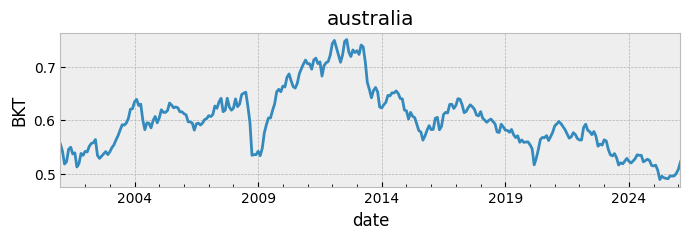

In [13]:
bkt_price('australia')

Since 2001-01-01,
1 unit of sweden money was worth at least 0.073 BKT
1 unit of sweden money had a mean value of 0.097 BKT
1 unit of sweden money was worth at most 0.116 BKT
(max - min) was 44% of mean


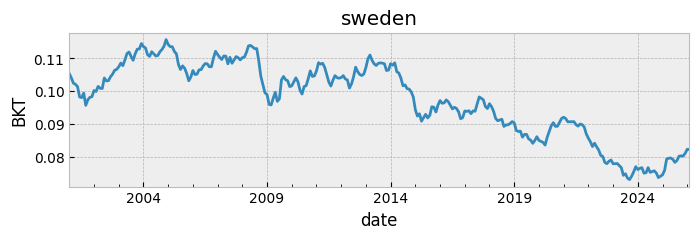

In [14]:
bkt_price('sweden')

Since 2001-01-01,
1 unit of malaysia money was worth at least 0.167 BKT
1 unit of malaysia money had a mean value of 0.211 BKT
1 unit of malaysia money was worth at most 0.279 BKT
(max - min) was 53% of mean


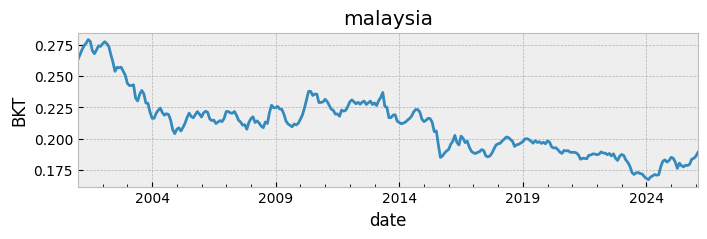

In [15]:
bkt_price('malaysia')

Since 2001-01-01,
1 unit of japan money was worth at least 0.005 BKT
1 unit of japan money had a mean value of 0.007 BKT
1 unit of japan money was worth at most 0.009 BKT
(max - min) was 63% of mean


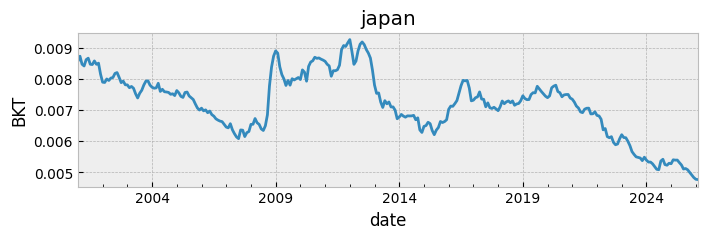

In [16]:
bkt_price('japan')

Since 2001-01-01,
1 unit of india money was worth at least 0.008 BKT
1 unit of india money had a mean value of 0.014 BKT
1 unit of india money was worth at most 0.023 BKT
(max - min) was 102% of mean


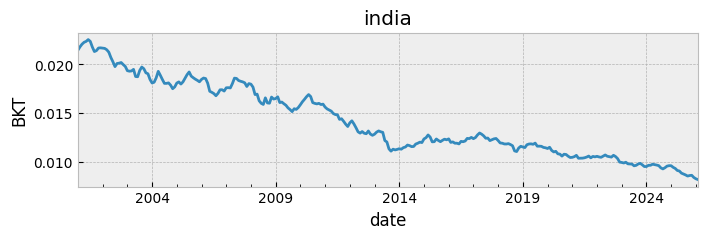

In [17]:
bkt_price('india')

Since 2001-01-01,
1 unit of south_africa money was worth at least 0.041 BKT
1 unit of south_africa money had a mean value of 0.080 BKT
1 unit of south_africa money was worth at most 0.135 BKT
(max - min) was 119% of mean


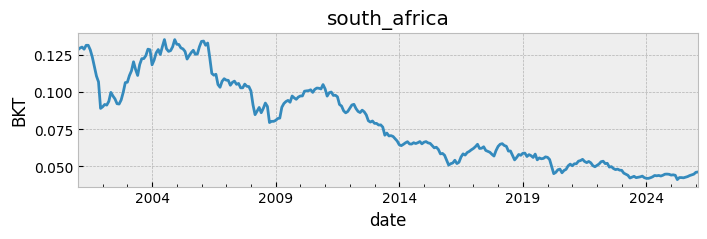

In [18]:
bkt_price('south_africa')

Since 2001-01-01,
1 unit of brazil money was worth at least 0.133 BKT
1 unit of brazil money had a mean value of 0.284 BKT
1 unit of brazil money was worth at most 0.511 BKT
(max - min) was 133% of mean


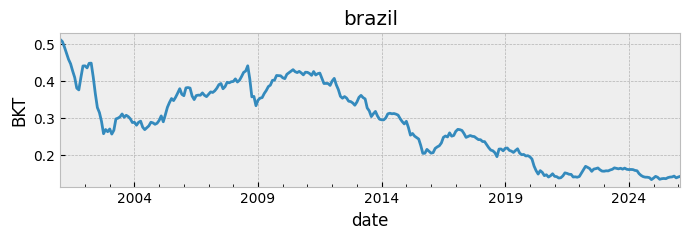

In [19]:
bkt_price('brazil')

Since 2001-01-01,
1 unit of mexico money was worth at least 0.035 BKT
1 unit of mexico money had a mean value of 0.058 BKT
1 unit of mexico money was worth at most 0.117 BKT
(max - min) was 142% of mean


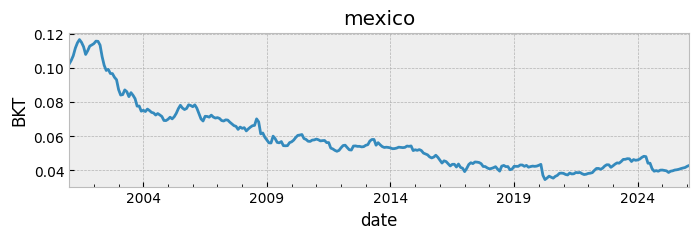

In [20]:
bkt_price('mexico')

Since 2001-01-01,
1 unit of venezuela money was worth at least 0.000 BKT
1 unit of venezuela money had a mean value of 0.254 BKT
1 unit of venezuela money was worth at most 1.479 BKT
(max - min) was 582% of mean


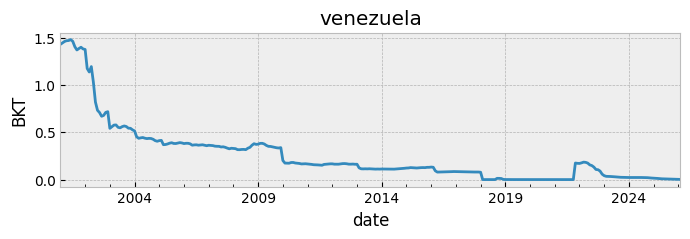

In [21]:
bkt_price('venezuela')